## Linear Regression from scratch
#### It is supervised regression algorithm
<a href="https://www.youtube.com/watch?v=VmbA0pi2cRQ"> https://www.youtube.com/watch?v=VmbA0pi2cRQ </a> 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Datasets/Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [77]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [78]:
df.nunique()

YearsExperience    28
Salary             30
dtype: int64

In [79]:
len(df)

30

Calculate cost function. Implement a function which returns cost given true y values, x values and parameters (w).<br>
<div><img src="https://i.stack.imgur.com/O752N.png" width="400"></div>

### Explanation: 
 - Hypothesis or model function is the function that accepts training set and makes prediction. Coefficients (tetas) can also be replaced with w and b. <br>
 - Model function it the linear function that will be shown in the graph fitting data. <br>
 - The cost function represents how the outputs predicted by model function fits the actual values and determine the error. Thus, it is a must for us to minimize the cost function. (m - number of training examples). <br>
 - w and b are the parameters of the model that can be adjusted to better fit the training data.

In [80]:
def model_function(x,w,b = 0): # Hypothesis --> h(x) = wx + b
    return w*x + b

def cost_function(x, y_actual, w, b = 0):
    s = sum((model_function(x,w,b) - y_actual)**2)
    return s/(2*len(x))

In [81]:
w_entrance = np.linspace(-75000,100000,10000)
J = [cost_function(df["YearsExperience"], df["Salary"], i, 5) for i in w_entrance]
print(J)

[140350882632.86667, 140295256698.54358, 140239641796.53094, 140184037926.82886, 140128445089.4373, 140072863284.35626, 140017292511.58575, 139961732771.1257, 139906184062.9762, 139850646387.13724, 139795119743.6088, 139739604132.39084, 139684099553.48343, 139628606006.88654, 139573123492.60013, 139517652010.6243, 139462191560.95892, 139406742143.6041, 139351303758.55978, 139295876405.82596, 139240460085.40274, 139185054797.29, 139129660541.4877, 139074277317.99603, 139018905126.8148, 138963543967.94418, 138908193841.384, 138852854747.13434, 138797526685.19525, 138742209655.5666, 138686903658.2485, 138631608693.241, 138576324760.54388, 138521051860.15738, 138465789992.08136, 138410539156.31586, 138355299352.8609, 138300070581.7164, 138244852842.88248, 138189646136.35907, 138134450462.14618, 138079265820.2438, 138024092210.65195, 137968929633.3706, 137913778088.39975, 137858637575.73944, 137803508095.38968, 137748389647.35037, 137693282231.6216, 137638185848.20334, 137583100497.09567, 1

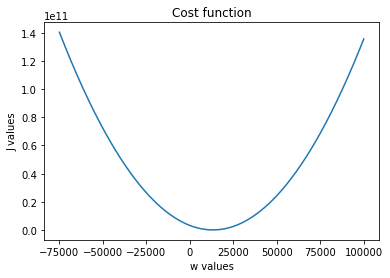

In [82]:
plt.plot(w_entrance, J)
plt.title('Cost function')
plt.xlabel('w values')
plt.ylabel('J values')
plt.show()

Gradient descent is an algorithm for finding values of parameters w and b that minimize the cost function J.  What does this update statement do? (Assume alpha (learning rate) is small.) 
<img src="https://media.geeksforgeeks.org/wp-content/uploads/20200611183120/1406-7.png">
<br>
<img src="https://studymachinelearning.com/wp-content/uploads/2019/10/exaple_batchcGD.png">
<br>
<img src="https://i.stack.imgur.com/3MhPr.png">

In [83]:
def func_gradient(x, y_actual, w, b = 0):
    s1 = sum((model_function(x,w,b) - y_actual)*x)
    s2 = sum(model_function(x,w,b) - y_actual)
    return s1/len(x), s2/len(x)

In [84]:
def gradient_descent(x, y_actual,w,b,n = 10000, alpha = 0.001):
    for i in range(n):
        sbtr1, sbtr2 = func_gradient(x, y_actual, w, b)
        print(sbtr1, sbtr2)
        w -= sbtr1*alpha
        b -= sbtr2*alpha
        print(w,b)
        print("------------------------------------------------------")
    return w,b

w, b = gradient_descent(df["YearsExperience"], df["Salary"], 0.001, 0.001)
w,b

-477398.6586699999 -76002.99368666667
477.3996586699999 76.00399368666667
------------------------------------------------------
-459800.5210737803 -73390.41248658007
937.2001797437802 149.39440617324675
------------------------------------------------------
-442850.0912480944 -70873.94863878813
1380.0502709918746 220.2683548120349
------------------------------------------------------
-426523.5302145414 -68450.06453865113
1806.5738012064162 288.718419350686
------------------------------------------------------
-410797.87639173225 -66115.35278357255
2217.3716775981484 354.8337721342586
------------------------------------------------------
-395651.01330256666 -63866.531380894245
2613.022690900715 418.7003035151528
------------------------------------------------------
-381061.6384700487 -61700.43913216572
2994.084329370764 480.40074264731857
------------------------------------------------------
-367009.23345789686 -59614.03118729602
3361.0935628286607 540.0147738346146
--------------

650.881506241988 -4808.089535899152
12814.41618577387 3108.995536155078
------------------------------------------------------
652.9859063928996 -4806.739796766426
12813.763199867479 3113.8022759518444
------------------------------------------------------
655.0073414511629 -4805.402588752285
12813.108192526028 3118.6076785405967
------------------------------------------------------
656.948866124813 -4804.077458504443
12812.451243659903 3123.411755999101
------------------------------------------------------
658.8134226927369 -4802.763969354613
12811.79243023721 3128.2145199684555
------------------------------------------------------
660.6038451425954 -4801.4617007045
12811.131826392068 3133.01598166916
------------------------------------------------------
662.3228631564377 -4800.170247434321
12810.469503528911 3137.816151916594
------------------------------------------------------
663.973105949794 -4798.889219333126
12809.805530422962 3142.615041135927
----------------------------

673.6083184045526 -4539.289655149221
12633.858009901982 4336.77163636161
------------------------------------------------------
673.4659511710576 -4538.3294710258615
12633.18454395081 4341.3099658326355
------------------------------------------------------
673.3236097524263 -4537.369490642058
12632.511220341059 4345.847335323278
------------------------------------------------------
673.1812943015132 -4536.409713931231
12631.838039046757 4350.383745037208
------------------------------------------------------
673.0390049650857 -4535.450140827686
12631.165000041792 4354.919195178036
------------------------------------------------------
672.8967418845016 -4534.490771266577
12630.492103299908 4359.453685949303
------------------------------------------------------
672.7545051956733 -4533.53160518385
12629.819348794712 4363.987217554487
------------------------------------------------------
672.6122950290417 -4532.572642516278
12629.146736499682 4368.519790197003
------------------------

629.7871706023415 -4243.968587124462
12426.717734205018 5732.635551220196
------------------------------------------------------
629.6539557673755 -4243.0708877038105
12426.08808024925 5736.8786221079
------------------------------------------------------
629.5207691104879 -4242.173378167749
12425.45855948014 5741.120795486067
------------------------------------------------------
629.3876106256755 -4241.2760584761245
12424.829171869513 5745.362071544543
------------------------------------------------------
629.2544803069575 -4240.378928588781
12424.199917389205 5749.602450473132
------------------------------------------------------
629.1213781484645 -4239.481988465557
12423.570796011058 5753.841932461598
------------------------------------------------------
628.9883041442149 -4238.585238066317
12422.941807706913 5758.080517699665
------------------------------------------------------
628.8552582881917 -4237.688677350937
12422.312952448625 5762.3182063770155
------------------------

593.0643371444434 -3996.5031591406255
12253.143392857814 6902.306968122638
------------------------------------------------------
592.9388900538669 -3995.6578044928474
12252.55045396776 6906.302625927131
------------------------------------------------------
592.8134694983062 -3994.812628657505
12251.957640498262 6910.297438555788
------------------------------------------------------
592.6880754721492 -3993.967631596778
12251.36495242279 6914.291406187385
------------------------------------------------------
592.5627079697714 -3993.1228132728593
12250.772389714819 6918.284529000658
------------------------------------------------------
592.4373669855423 -3992.278173647939
12250.179952347833 6922.276807174306
------------------------------------------------------
592.3120525139316 -3991.433712684208
12249.58764029532 6926.26824088699
------------------------------------------------------
592.1867645493035 -3990.5894303438777
12248.99545353077 6930.258830317333
------------------------

...

------------------------------------------------------
107.00102391448793 -721.0515003552823
9955.713934006571 22384.074316349757
------------------------------------------------------
106.97839067504682 -720.8989809619942
9955.606955615896 22384.79521533072
------------------------------------------------------
106.95576222308203 -720.7464938301521
9955.499999853673 22385.51596182455
------------------------------------------------------
106.93313855757394 -720.5940389529331
9955.393066715116 22386.236555863503
------------------------------------------------------
106.91051967752888 -720.4416163235112
9955.286156195438 22386.956997479825
------------------------------------------------------
106.8879055818133 -720.289225935083
9955.179268289856 22387.67728670576
------------------------------------------------------
106.86529626956981 -720.1368677808072
9955.072402993586 22388.39742357354
------------------------------------------------------
106.84269173972474 -719.9845418538736
995

------------------------------------------------------
101.72559277626279 -685.501770100267
9930.779052942744 22552.103861717773
------------------------------------------------------
101.70407541491755 -685.3567703131155
9930.67734886733 22552.789218488087
------------------------------------------------------
101.68256260504883 -685.2118011968315
9930.575666304725 22553.474430289283
------------------------------------------------------
101.66105434556108 -685.0668627449454
9930.47400525038 22554.159497152028
------------------------------------------------------
101.63955063562632 -684.9219549509537
9930.372365699744 22554.84441910698
------------------------------------------------------
101.6180514742077 -684.7770778083789
9930.27074764827 22555.529196184787
------------------------------------------------------
101.59655686035839 -684.6322313107382
9930.16915109141 22556.213828416097
------------------------------------------------------
101.57506679314126 -684.4874154515448
9930

98.29847141642676 -662.4073088698655
9914.580402773472 22661.2622658245
------------------------------------------------------
98.27767897207814 -662.2671941057832
9914.4821250945 22661.924533018606
------------------------------------------------------
98.25689092578857 -662.1271089792809
9914.383868203575 22662.586660127585
------------------------------------------------------
98.23610727663763 -661.9870534840901
9914.285632096298 22663.24864718107
------------------------------------------------------
98.21532802376557 -661.8470276139312
9914.187416768274 22663.910494208685
------------------------------------------------------
98.19455316616295 -661.7070313625501
9914.089222215109 22664.572201240047
------------------------------------------------------
98.17378270295764 -661.5670647236742
9913.991048432406 22665.23376830477
------------------------------------------------------
98.15301663316374 -661.4271276910466
9913.892895415773 22665.895195432462
-----------------------------

9887.76632293552 22841.95523296157
------------------------------------------------------
92.605868863465 -624.0463711743657
9887.673717066657 22842.579279332742
------------------------------------------------------
92.58628053871313 -623.9143706530898
9887.581130786119 22843.203193703393
------------------------------------------------------
92.56669635738848 -623.7823980530314
9887.488564089761 22843.826976101445
------------------------------------------------------
92.54711631856675 -623.6504533682921
9887.396016973442 22844.450626554815
------------------------------------------------------
92.5275404213741 -623.5185365929647
9887.303489433021 22845.074145091407
------------------------------------------------------
92.50796866497525 -623.3866477211426
9887.210981464355 22845.697531739126
------------------------------------------------------
92.48840104842505 -623.2547867469317
9887.118493063306 22846.320786525874
------------------------------------------------------
92.4688375

(9876.9729493707, 22914.688912678845)

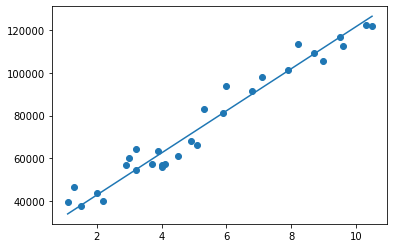

In [85]:
x = [i for i in df["YearsExperience"]]
y = [w*i + b for i in df["YearsExperience"]]
plt.scatter(df["YearsExperience"], df["Salary"])
plt.plot(x, y)

## Linear Regression library

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df["YearsExperience"]
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)

X_train = np.array(X_train).reshape(-1,1)
y_train = np.array(y_train).reshape(-1,1)
X_test = np.array(X_test).reshape(-1,1)


ln = LinearRegression()
ln_model = ln.fit(X_train, y_train)
y_pred = ln_model.predict(X_test)
r2_score(y_pred, y_test)

0.993216174839293

## Comparing algorithm typed from scratch with the real library

In [88]:
# Finding w, b based on training data
w, b = gradient_descent(X_train, y_train, 0.001, 0.001)

# Predicting values
y_pred = [w*i + b for i in X_test]

# Score
r2_score(y_pred, y_test)

[-456413.90654958] [-74697.7855125]
[456.41490655] [74.69878551]
------------------------------------------------------
[-440451.68525534] [-72270.65438365]
[896.8665918] [146.9694399]
------------------------------------------------------
[-425046.75776131] [-69928.22233484]
[1321.91334957] [216.89766223]
------------------------------------------------------
[-410179.66730912] [-67667.53228188]
[1732.09301688] [284.56519451]
------------------------------------------------------
[-395831.63643275] [-65485.73038101]
[2127.92465331] [350.05092489]
------------------------------------------------------
[-381984.54324248] [-63380.06242451]
[2509.90919655] [413.43098732]
------------------------------------------------------
[-368620.89853676] [-61347.87036213]
[2878.53009509] [474.77885768]
------------------------------------------------------
[-355723.82371325] [-59386.58894389]
[3234.2539188] [534.16544662]
------------------------------------------------------
[-343277.02945099] [-57

[702.68715835] [-4933.1911449]
[12894.1055099] [3307.54313056]
------------------------------------------------------
[704.13122778] [-4931.87972048]
[12893.40137868] [3312.47501028]
------------------------------------------------------
[705.51925242] [-4930.57705047]
[12892.69585942] [3317.40558733]
------------------------------------------------------
[706.85319018] [-4929.28283723]
[12891.98900623] [3322.33487017]
------------------------------------------------------
[708.13493062] [-4927.99679354]
[12891.2808713] [3327.26286696]
------------------------------------------------------
[709.3662973] [-4926.7186422]
[12890.571505] [3332.1895856]
------------------------------------------------------
[710.54905014] [-4925.44811569]
[12889.86095595] [3337.11503372]
------------------------------------------------------
[711.68488762] [-4924.1849558]
[12889.14927107] [3342.03921867]
------------------------------------------------------
[712.7754489] [-4922.92891337]
[12888.43649562] [

[12694.1115584] [4632.00632356]
------------------------------------------------------
[704.92503451] [-4638.21868583]
[12693.40663337] [4636.64454225]
------------------------------------------------------
[704.77238895] [-4637.21376826]
[12692.70186098] [4641.28175602]
------------------------------------------------------
[704.6197736] [-4636.20906885]
[12691.99724121] [4645.91796508]
------------------------------------------------------
[704.46718856] [-4635.20458753]
[12691.29277402] [4650.55316967]
------------------------------------------------------
[704.31463392] [-4634.20032425]
[12690.58845938] [4655.18737]
------------------------------------------------------
[704.16210977] [-4633.19627893]
[12689.88429727] [4659.82056627]
------------------------------------------------------
[704.00961618] [-4632.19245153]
[12689.18028766] [4664.45275873]
------------------------------------------------------
[703.85715325] [-4631.18884197]
[12688.4764305] [4669.08394757]
-------------

[668.62584837] [-4399.36467841]
[12525.89037665] [5738.85349424]
------------------------------------------------------
[668.48098554] [-4398.41152279]
[12525.22189566] [5743.25190577]
------------------------------------------------------
[668.33615409] [-4397.45857368]
[12524.55355951] [5747.64936434]
------------------------------------------------------
[668.19135402] [-4396.50583103]
[12523.88536815] [5752.04587017]
------------------------------------------------------
[668.04658533] [-4395.55329481]
[12523.21732157] [5756.44142347]
------------------------------------------------------
[667.901848] [-4394.60096495]
[12522.54941972] [5760.83602443]
------------------------------------------------------
[667.75714203] [-4393.64884143]
[12521.88166258] [5765.22967327]
------------------------------------------------------
[667.6124674] [-4392.69692419]
[12521.21405011] [5769.6223702]
------------------------------------------------------
[667.46782413] [-4391.74521319]
[12520.54658

------------------------------------------------------
[638.19138323] [-4199.11469855]
[12385.44814282] [6662.9227686]
------------------------------------------------------
[638.05311424] [-4198.20492861]
[12384.81008971] [6667.12097353]
------------------------------------------------------
[637.91487521] [-4197.29535577]
[12384.17217483] [6671.31826889]
------------------------------------------------------
[637.77666613] [-4196.38598]
[12383.53439816] [6675.51465487]
------------------------------------------------------
[637.638487] [-4195.47680126]
[12382.89675968] [6679.71013167]
------------------------------------------------------
[637.5003378] [-4194.56781949]
[12382.25925934] [6683.90469949]
------------------------------------------------------
[637.36221853] [-4193.65903466]
[12381.62189712] [6688.09835852]
------------------------------------------------------
[637.22412919] [-4192.75044673]
[12380.98467299] [6692.29110897]
-----------------------------------------------

...

[106.92237361] [-703.51829001]
[9933.86553235] [22793.62720125]
------------------------------------------------------
[106.89920807] [-703.36586746]
[9933.75863314] [22794.33056711]
------------------------------------------------------
[106.87604755] [-703.21347792]
[9933.65175709] [22795.03378059]
------------------------------------------------------
[106.85289204] [-703.06112141]
[9933.5449042] [22795.73684171]
------------------------------------------------------
[106.82974156] [-702.9087979]
[9933.43807446] [22796.43975051]
------------------------------------------------------
[106.80659609] [-702.7565074]
[9933.33126786] [22797.14250702]
------------------------------------------------------
[106.78345563] [-702.60424989]
[9933.2244844] [22797.84511127]
------------------------------------------------------
[106.76032019] [-702.45202536]
[9933.11772408] [22798.54756329]
------------------------------------------------------
[106.73718976] [-702.29983382]
[9933.01098689] [2279

[9910.89696178] [22944.75375167]
------------------------------------------------------
[101.92289362] [-670.62315781]
[9910.79503889] [22945.42437482]
------------------------------------------------------
[101.90081125] [-670.47786224]
[9910.69313808] [22946.09485269]
------------------------------------------------------
[101.87873367] [-670.33259814]
[9910.59125934] [22946.76518529]
------------------------------------------------------
[101.85666087] [-670.18736551]
[9910.48940268] [22947.43537265]
------------------------------------------------------
[101.83459286] [-670.04216435]
[9910.38756809] [22948.10541482]
------------------------------------------------------
[101.81252962] [-669.89699465]
[9910.28575556] [22948.77531181]
------------------------------------------------------
[101.79047117] [-669.75185641]
[9910.18396509] [22949.44506367]
------------------------------------------------------
[101.76841749] [-669.6067496]
[9910.08219667] [22950.11467042]
----------------

[9885.80182192] [23109.87251293]
------------------------------------------------------
[96.48584185] [-634.84892991]
[9885.70533608] [23110.50736186]
------------------------------------------------------
[96.46493746] [-634.71138509]
[9885.60887114] [23111.14207325]
------------------------------------------------------
[96.44403761] [-634.57387007]
[9885.51242711] [23111.77664712]
------------------------------------------------------
[96.42314228] [-634.43638484]
[9885.41600396] [23112.4110835]
------------------------------------------------------
[96.40225147] [-634.29892941]
[9885.31960171] [23113.04538243]
------------------------------------------------------
[96.3813652] [-634.16150375]
[9885.22322035] [23113.67954394]
------------------------------------------------------
[96.36048345] [-634.02410786]
[9885.12685986] [23114.31356804]
------------------------------------------------------
[96.33960622] [-633.88674175]
[9885.03052026] [23114.94745478]
-------------------------

[91.6560401] [-603.07023144]
[9863.4178362] [23257.15266422]
------------------------------------------------------
[91.63618212] [-602.93957172]
[9863.32620001] [23257.75560379]
------------------------------------------------------
[91.61632845] [-602.8089403]
[9863.23458369] [23258.35841273]
------------------------------------------------------
[91.59647908] [-602.67833719]
[9863.14298721] [23258.96109107]
------------------------------------------------------
[91.57663401] [-602.54776237]
[9863.05141057] [23259.56363883]
------------------------------------------------------
[91.55679324] [-602.41721584]
[9862.95985378] [23260.16605605]
------------------------------------------------------
[91.53695677] [-602.2866976]
[9862.86831682] [23260.76834275]
------------------------------------------------------
[91.5171246] [-602.15620763]
[9862.7767997] [23261.37049895]
------------------------------------------------------
[91.49729672] [-602.02574594]
[9862.6853024] [23261.9725247]
-

0.9935985117631928

The number of samples in 'Salary' dataset is extremely low, that is why it is needy to apply LinearRegression on another dataset

In [33]:
turbo = pd.read_csv('Datasets/turboaz.csv')
turbo.head()

,Sheher,Marka,Model,Buraxilish ili,Ban novu,Reng,Muherrikin hecmi,Muherrikin gucu,Yanacaq novu,Yurush,Suretler qutusu,Oturucu,Yeni,Qiymet,Extra Info,Seller comment
0,Sumqayıt,Mercedes,C 200,1999,Sedan,Qara,2.0 L,175 a.g.,Benzin,366 000 km,Avtomat,Arxa,Xeyr,12500 AZN,Kreditdədir,Barter mümkündür
1,Bakı,Mercedes,C 180,2014,Sedan,Qara,1.6 L,167 a.g.,Benzin,102 000 km,Avtomat,Arxa,Xeyr,31500 $,Barter mümkündür,"Yüngül lehimli disklər,ABS,Yağış sensoru,Mərkə..."
2,Sumqayıt,Mercedes,C 240,2002,Sedan,Qara,2.6 L,177 a.g.,Benzin,469 700 km,Avtomat,Arxa,Xeyr,11700 AZN,Kreditdədir,Barter mümkündür
3,Şirvan,Mercedes,C 180,1998,Sedan,Göy,1.8 L,125 a.g.,Benzin,556 680 km,Avtomat,Arxa,Xeyr,9700 AZN,"Yüngül lehimli disklər,ABS,Mərkəzi qapanma,Kon...",Mawin BAKIDADI. Tecili satilir yaxwi veziyetde...
4,Sumqayıt,Mercedes,C 220,2000,Sedan,Gümüşü,2.2 L,150 a.g.,Dizel,300 000 km,Avtomat,Arxa,Xeyr,12700 AZN,"Yüngül lehimli disklər,ABS,Mərkəzi qapanma,Par...",Vurugu udari deyisen detali curuyu qetiyyen yo...


#### In this assignment, you will use a turbo.az dataset which is a collection of cars (Mercedes C-class). It contains information about 1328 cars with features of (Sheher, Marka, Model, Buraxilish ili, Ban novu, Reng, Muherrikin hecmi, Muherrikin gucu, Yanacaq novu, Yurush, Suretler qutusu, Oturucu, Yeni, Qiymet, Extra Information, Seller’s comment). You will need to read the data from data file (turboaz.csv) and extract only 3 columns for your model:
X1 - Yurush (mileage)<br>
X2 - Buraxilish ili (model year)<br>
Y - Qiymet (price)

### Data Preprocessing

In [36]:
needy_columns = ["Buraxilish ili","Yurush","Qiymet"]
data = turbo[needy_columns].copy()      # Extracted columns
data['Yurush'] = data['Yurush'].str.replace("km","").str.replace(" ","")
data['Yurush'] = data['Yurush'].astype('int64')

currency = data["Qiymet"].apply(lambda x: x.split()[1])
data["currency"] = currency

print(data["currency"].unique())
data.head()

['AZN' '$']


,Buraxilish ili,Yurush,Qiymet,currency
0,1999,366000,12500 AZN,AZN
1,2014,102000,31500 $,$
2,2002,469700,11700 AZN,AZN
3,1998,556680,9700 AZN,AZN
4,2000,300000,12700 AZN,AZN


In [37]:
def exchange_to_AZN(val, curr):
    if curr == "$":
        return int(val)*1.7
    return int(val)

data["Qiymet"] = data["Qiymet"].apply(lambda x: exchange_to_AZN(x.split()[0], x.split()[1]))
data.drop(["currency"], axis = 1, inplace = True)
data.head()

,Buraxilish ili,Yurush,Qiymet
0,1999,366000,12500.0
1,2014,102000,53550.0
2,2002,469700,11700.0
3,1998,556680,9700.0
4,2000,300000,12700.0


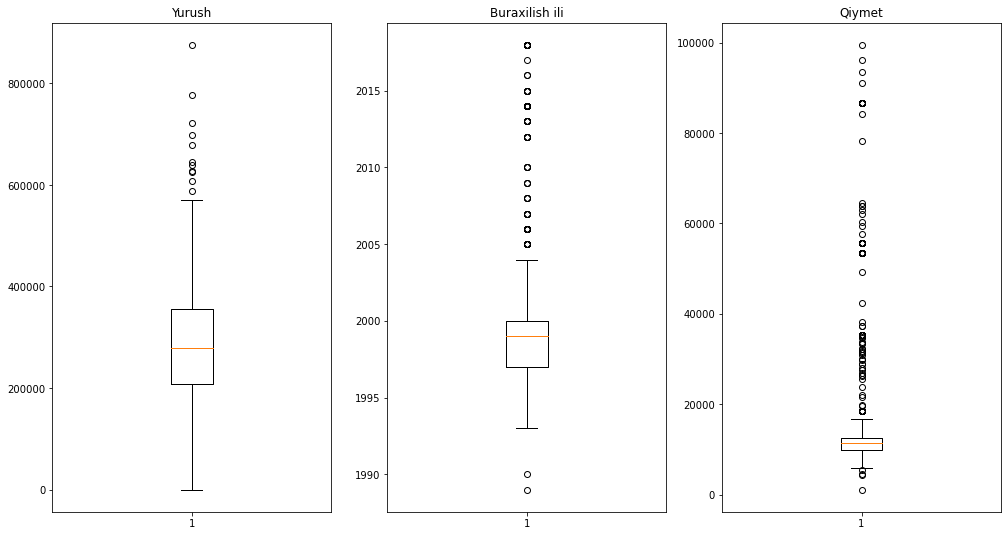

In [38]:
# This code just aims to display outliers, no special purpose
fig, axs = plt.subplots(1, 3)
fig.set_size_inches(17, 9)

axs[0].boxplot(data["Yurush"])
axs[0].set_title('Yurush')

axs[1].boxplot(data["Buraxilish ili"])
axs[1].set_title("Buraxilish ili")

axs[2].boxplot(data["Qiymet"])
axs[2].set_title("Qiymet")

plt.show()

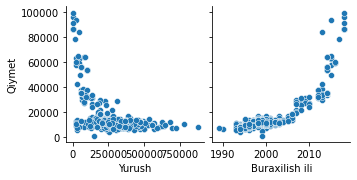

In [39]:
import seaborn as sns
sns.pairplot(data,y_vars=['Qiymet'], x_vars=['Yurush','Buraxilish ili'])

In [48]:
data.corr()

,Buraxilish ili,Yurush,Qiymet
Buraxilish ili,1.000000,-0.570556,0.884125
Yurush,-0.570556,1.000000,-0.567400
Qiymet,0.884125,-0.567400,1.000000


### Applied Linear Regression algorithm

In [43]:
X = data[["Yurush", "Buraxilish ili"]]
y = data["Qiymet"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)

ln = LinearRegression()
ln_model = ln.fit(X_train, y_train)
y_pred = ln_model.predict(X_test)
r2_score(y_pred, y_test)

0.6839311149539875

### Removing some outliers, then apply Linear Regression

In [67]:
len(data[data["Yurush"] > 600000])  # There are 1328 samples

10

In [68]:
new_data = data.copy()
new_data = new_data[(new_data["Yurush"] < 600000) & (new_data["Qiymet"] < 60000)]
new_data.corr()

,Buraxilish ili,Yurush,Qiymet
Buraxilish ili,1.000000,-0.517070,0.892028
Yurush,-0.517070,1.000000,-0.535619
Qiymet,0.892028,-0.535619,1.000000


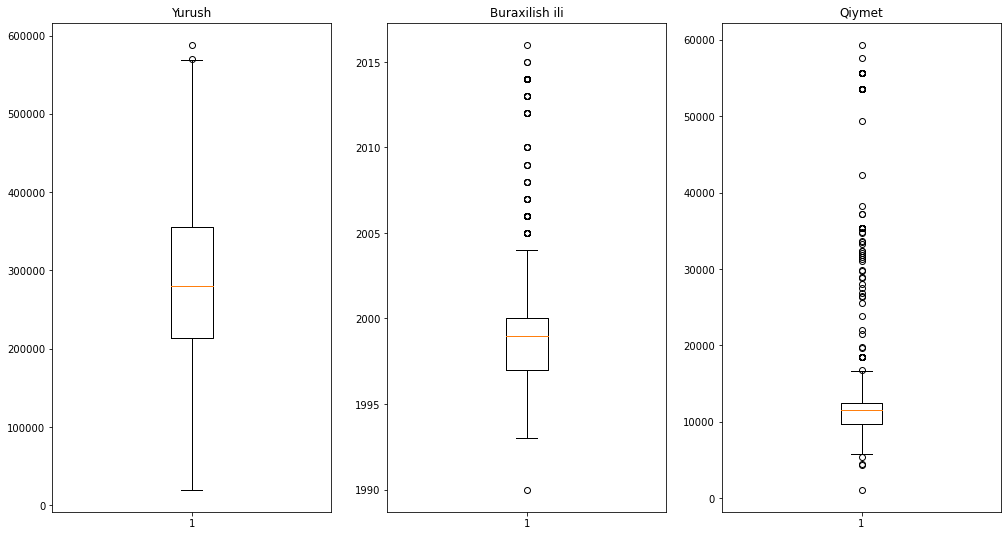

In [69]:
fig, axs = plt.subplots(1, 3)
fig.set_size_inches(17, 9)

axs[0].boxplot(new_data["Yurush"])
axs[0].set_title('Yurush')

axs[1].boxplot(new_data["Buraxilish ili"])
axs[1].set_title("Buraxilish ili")

axs[2].boxplot(new_data["Qiymet"])
axs[2].set_title("Qiymet")

plt.show()

In [70]:
# from sklearn.model_selection import LinearRegression
X = new_data[["Yurush", "Buraxilish ili"]]
y = new_data["Qiymet"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)

ln = LinearRegression()
ln_model = ln.fit(X_train, y_train)
y_pred = ln_model.predict(X_test)
r2_score(y_pred, y_test)
# ln_model.score(y_pred, y_test)

0.75010685663579

### For more details search the book named Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow
- <h4> Gradient Descent </h4>
- <h4> Stochastic Gradient Descent </h4>
- <h4> Batch Gradient Descent and so on</h4>